# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rohmasaeed/flyrank-ml-internship-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Which pages should be reviewed first for refresh, expansion, protection,
pruning, or monitoring based on observed search and engagement signals?

### Decision Supported

The goal is to build a repeatable content-opportunity scoring system that
helps prioritize pages for human review.

The system is intended as decision support. It does not claim that a
recommended refresh will cause future performance improvement.

### Lane

This capstone follows Lane 2: Refresh / Content Opportunity Scoring.

The analysis uses historical page-level performance signals to identify
pages that show evidence of deterioration, growth, recovery, or other
review-worthy patterns.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Install packages**

In [1]:
!pip install -q duckdb huggingface_hub pyarrow pandas scikit-learn matplotlib

In [2]:
from huggingface_hub import login

login()

**DuckDB connection**

In [3]:
import duckdb

con = duckdb.connect()

print("DuckDB connected successfully.")

DuckDB connected successfully.


**Dataset path**

In [4]:
HF_DATASET = "hf://datasets/FlyRank/internship-warehouse"

print(HF_DATASET)

hf://datasets/FlyRank/internship-warehouse


In [5]:
import os
from huggingface_hub import get_token

token = get_token()

print("Token available:", token is not None)

Token available: True


In [6]:
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{token}'
)
""")

print("Hugging Face authentication configured for DuckDB.")

Hugging Face authentication configured for DuckDB.


**dim_content inspect**

In [7]:
content_sample = con.sql(f"""
    SELECT *
    FROM read_parquet('{HF_DATASET}/dim_content.parquet')
    LIMIT 5
""").df()

content_sample

,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


**Daily performance inspect**

In [8]:
performance_sample = con.sql(f"""
    SELECT *
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet'
    )
    LIMIT 5
""").df()

performance_sample

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [9]:
performance_sample.columns.tolist()

['report_date',
 'client_hash_id',
 'content_hash_id',
 'client_has_gsc',
 'client_has_ga4',
 'gsc_data_available',
 'ga4_data_available',
 'gsc_impressions',
 'gsc_clicks',
 'gsc_sum_position',
 'gsc_avg_position',
 'ga4_pageviews',
 'ga4_sessions',
 'ga4_users',
 'ga4_engaged_sessions',
 'ga4_total_engagement_sec',
 'sessions_organic',
 'sessions_direct',
 'sessions_referral',
 'sessions_social',
 'sessions_paid',
 'sessions_ai',
 'ai_chatgpt',
 'ai_perplexity',
 'ai_gemini',
 'ai_copilot',
 'ai_claude',
 'ai_meta',
 'ai_other',
 'scroll_events',
 'month']

**warehouse ka actual date coverage**

In [10]:
months = con.sql(f"""
    SELECT DISTINCT month
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )
    ORDER BY month
""").df()

months

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month
0,2025-01
1,2025-02
2,2025-03
3,2025-04
4,2025-05
5,2025-06
6,2025-07
7,2025-08
8,2025-09
9,2025-10


**Check rows in month**

In [11]:
monthly_counts = con.sql(f"""
    SELECT
        month,
        COUNT(*) AS rows
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )
    GROUP BY month
    ORDER BY month
""").df()

monthly_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471


In [12]:
content_monthly = con.sql(f"""
    SELECT
        month,
        COUNT(DISTINCT content_hash_id) AS unique_pages,
        COUNT(*) AS performance_rows
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )
    WHERE month >= '2025-09'
    GROUP BY month
    ORDER BY month
""").df()

content_monthly

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,unique_pages,performance_rows
0,2025-09,53127,845813
1,2025-10,110339,2165471
2,2025-11,251384,6793825
3,2025-12,254621,7752930
4,2026-01,261984,7890817
5,2026-02,321546,7355108
6,2026-03,331437,9841378
7,2026-04,362172,10424730
8,2026-05,389153,11687376
9,2026-06,409205,11694072


**how many pages have enough consecutive daily data**

In [13]:
coverage = con.sql(f"""
    SELECT
        content_hash_id,
        COUNT(DISTINCT report_date) AS active_days,
        MIN(report_date) AS first_seen,
        MAX(report_date) AS last_seen
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )
    WHERE report_date >= '2025-10-01'
      AND report_date <= '2026-06-30'
    GROUP BY content_hash_id
    LIMIT 100000
""").df()

coverage.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_hash_id,active_days,first_seen,last_seen
0,content_27d8221f9191e369,273,2025-10-01,2026-06-30
1,content_064b174854b62a19,273,2025-10-01,2026-06-30
2,content_9732385705d7914d,273,2025-10-01,2026-06-30
3,content_44677b2ffd7549a9,264,2025-10-02,2026-06-30
4,content_84b4a576a4379876,273,2025-10-01,2026-06-30


**Modeling windows**




In [14]:
FEATURE_DAYS = 28
FUTURE_DAYS = 28

TRAIN_START = "2025-10-01"
FINAL_CUTOFF = "2026-05-31"

print("Feature window:", FEATURE_DAYS, "days")
print("Future window:", FUTURE_DAYS, "days")
print("Training start:", TRAIN_START)
print("Final cutoff:", FINAL_CUTOFF)

Feature window: 28 days
Future window: 28 days
Training start: 2025-10-01
Final cutoff: 2026-05-31


In [15]:
cutoffs = con.sql("""
    SELECT cutoff_date
    FROM generate_series(
        DATE '2025-10-29',
        DATE '2026-05-31',
        INTERVAL '14 days'
    ) AS t(cutoff_date)
""").df()

cutoffs

,cutoff_date
0,2025-10-29
1,2025-11-12
2,2025-11-26
3,2025-12-10
4,2025-12-24
5,2026-01-07
6,2026-01-21
7,2026-02-04
8,2026-02-18
9,2026-03-04


**Create the cutoff table inside DuckDB**

In [16]:
con.execute("""
CREATE OR REPLACE TEMP TABLE cutoffs AS
SELECT cutoff_date
FROM generate_series(
    DATE '2025-10-29',
    DATE '2026-05-27',
    INTERVAL '14 days'
) AS t(cutoff_date)
""")

print("Cutoff table created.")

Cutoff table created.


In [17]:
con.sql("SELECT * FROM cutoffs").df()

,cutoff_date
0,2025-10-29
1,2025-11-12
2,2025-11-26
3,2025-12-10
4,2025-12-24
5,2026-01-07
6,2026-01-21
7,2026-02-04
8,2026-02-18
9,2026-03-04


**Build the page-level dataset(DATA CHECK)**

In [18]:
# Check that our connection is still alive
print(con.sql("SELECT 1 AS connection_test").df())

   connection_test
0                1


In [19]:
date_check = con.sql(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT content_hash_id) AS pages,
        COUNT(DISTINCT report_date) AS days
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )
    WHERE report_date BETWEEN DATE '2025-10-02'
                          AND DATE '2026-06-24'
""").df()

date_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,pages,days
0,73438992,424135,266


### Modeling dataset

The full relevant warehouse data is processed inside DuckDB. The complete
daily performance release is not loaded into pandas because it contains
tens of millions of rows.

For each content page and cutoff date, the analysis creates features from
the previous 28 days and measures outcomes in the following 28 days.

This preserves the temporal structure of the problem and avoids using
future observations as model features.

In [21]:
daily_page = con.sql(f"""
    SELECT
        report_date,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_sec
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )
    WHERE report_date BETWEEN DATE '2025-10-02'
                          AND DATE '2026-06-24'
    GROUP BY
        report_date,
        content_hash_id
""")

print("Daily page-level aggregation created.")

Daily page-level aggregation created.


In [22]:
daily_page.limit(5).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,content_hash_id,impressions,clicks,avg_position,sessions,engaged_sessions,engagement_sec
0,2025-10-02,content_fdca35df693142cb,3.0,0.0,0.000000,0.0,0.0,0.0
1,2025-10-02,content_2a85ee8dccf2800c,13.0,0.0,1.769231,0.0,0.0,0.0
2,2025-10-02,content_7d06a04addf258de,19.0,0.0,2.368421,0.0,0.0,0.0
3,2025-10-02,content_4b9888bfaf1af2d5,11.0,0.0,13.000000,0.0,0.0,0.0
4,2025-10-02,content_211be65e33f34c03,3.0,0.0,6.333333,0.0,0.0,0.0


In [24]:
daily_page_count = con.sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT content_hash_id) AS pages,
        COUNT(DISTINCT report_date) AS days
    FROM daily_page
""").df()

daily_page_count

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,pages,days
0,73434732,424135,266


In [25]:
con.execute("""
CREATE OR REPLACE TEMP TABLE daily_page_small AS
SELECT
    report_date,
    content_hash_id,
    impressions,
    clicks,
    avg_position,
    sessions,
    engaged_sessions,
    engagement_sec
FROM daily_page
WHERE report_date >= DATE '2025-10-02'
  AND report_date <= DATE '2026-06-24'
""")

print("Daily modeling table created.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Daily modeling table created.


In [26]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT content_hash_id) AS pages,
    COUNT(DISTINCT report_date) AS days
FROM daily_page_small
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,pages,days
0,73434732,424135,266


In [27]:
model_data = con.sql("""
WITH cutoff_windows AS (

    SELECT
        cutoff_date,
        cutoff_date - INTERVAL '27 days' AS feature_start,
        cutoff_date AS feature_end,
        cutoff_date + INTERVAL '1 day' AS future_start,
        cutoff_date + INTERVAL '28 days' AS future_end
    FROM cutoffs

),

features AS (

    SELECT
        c.cutoff_date,
        p.content_hash_id,

        SUM(p.impressions) AS hist_impressions,
        SUM(p.clicks) AS hist_clicks,

        AVG(p.avg_position) AS hist_avg_position,

        SUM(p.sessions) AS hist_sessions,
        SUM(p.engaged_sessions) AS hist_engaged_sessions,
        SUM(p.engagement_sec) AS hist_engagement_sec,

        COUNT(DISTINCT p.report_date) AS hist_active_days

    FROM cutoff_windows c

    INNER JOIN daily_page_small p
        ON p.report_date BETWEEN c.feature_start AND c.feature_end

    GROUP BY
        c.cutoff_date,
        p.content_hash_id

),

future AS (

    SELECT
        c.cutoff_date,
        p.content_hash_id,

        SUM(p.impressions) AS future_impressions,
        SUM(p.clicks) AS future_clicks,

        AVG(p.avg_position) AS future_avg_position,

        SUM(p.sessions) AS future_sessions,
        SUM(p.engaged_sessions) AS future_engaged_sessions,
        SUM(p.engagement_sec) AS future_engagement_sec,

        COUNT(DISTINCT p.report_date) AS future_active_days

    FROM cutoff_windows c

    INNER JOIN daily_page_small p
        ON p.report_date BETWEEN c.future_start AND c.future_end

    GROUP BY
        c.cutoff_date,
        p.content_hash_id

)

SELECT
    f.cutoff_date,
    f.content_hash_id,

    f.hist_impressions,
    f.hist_clicks,
    f.hist_avg_position,
    f.hist_sessions,
    f.hist_engaged_sessions,
    f.hist_engagement_sec,
    f.hist_active_days,

    fu.future_impressions,
    fu.future_clicks,
    fu.future_avg_position,
    fu.future_sessions,
    fu.future_engaged_sessions,
    fu.future_engagement_sec,
    fu.future_active_days,

    CASE
        WHEN f.hist_impressions > 0
        THEN f.hist_clicks / f.hist_impressions
        ELSE 0
    END AS hist_ctr,

    CASE
        WHEN f.hist_sessions > 0
        THEN f.hist_engaged_sessions / f.hist_sessions
        ELSE 0
    END AS hist_engagement_rate,

    CASE
        WHEN fu.future_impressions > 0
        THEN fu.future_clicks / fu.future_impressions
        ELSE 0
    END AS future_ctr,

    CASE
        WHEN fu.future_sessions > 0
        THEN fu.future_engaged_sessions / fu.future_sessions
        ELSE 0
    END AS future_engagement_rate

FROM features f

INNER JOIN future fu
    ON f.cutoff_date = fu.cutoff_date
    AND f.content_hash_id = fu.content_hash_id

WHERE f.hist_active_days >= 14
  AND fu.future_active_days >= 14

""").df()

print("Model dataset shape:", model_data.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model dataset shape: (4228038, 20)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

## Feature window

For each page and cutoff date, features are calculated using the previous **28 days**.

The features include:

- historical impressions
- historical clicks
- historical CTR
- average search position
- historical sessions
- engaged sessions
- engagement rate
- engagement time
- number of active days

## Future window

The following **28 days** are used only to define the observed outcome.

No future-window metric is used as a model feature.

## Label definition

A page is considered a **refresh-opportunity page** when its future performance shows meaningful deterioration relative to its historical performance.

The primary label combines:

- decline in impressions
- decline in clicks
- decline in sessions

while requiring sufficient historical and future observations.

## Validation

Because the data is time-dependent, the evaluation uses a chronological split rather than a random split.

Earlier cutoff observations are used for training and later cutoff observations are reserved for testing.

## Leakage control

Future-window metrics are used only to create the target label.

They are not included among model features.

Client identifiers and URLs are not used as predictive features.

#Create target label

In [28]:
import numpy as np
import pandas as pd

df = model_data.copy()

# Relative changes between historical and future windows
df["impression_change"] = np.where(
    df["hist_impressions"] > 0,
    (df["future_impressions"] - df["hist_impressions"])
    / df["hist_impressions"],
    0
)

df["click_change"] = np.where(
    df["hist_clicks"] > 0,
    (df["future_clicks"] - df["hist_clicks"])
    / df["hist_clicks"],
    0
)

df["session_change"] = np.where(
    df["hist_sessions"] > 0,
    (df["future_sessions"] - df["hist_sessions"])
    / df["hist_sessions"],
    0
)

# Refresh opportunity:
# at least two major signals decline by 20% or more.
df["decline_signals"] = (
    (df["impression_change"] <= -0.20).astype(int)
    +
    (df["click_change"] <= -0.20).astype(int)
    +
    (df["session_change"] <= -0.20).astype(int)
)

df["refresh_opportunity"] = (
    df["decline_signals"] >= 2
).astype(int)

print(df["refresh_opportunity"].value_counts())

refresh_opportunity
0    3868857
1     359181
Name: count, dtype: int64


#Check label distribution

In [29]:
label_summary = pd.DataFrame({
    "count": df["refresh_opportunity"].value_counts(),
    "percentage": df["refresh_opportunity"].value_counts(normalize=True) * 100
})

label_summary

,count,percentage
refresh_opportunity,,
0,3868857,91.504783
1,359181,8.495217


# Add useful engineered features

In [31]:
df["log_impressions"] = np.log1p(df["hist_impressions"])
df["log_clicks"] = np.log1p(df["hist_clicks"])
df["log_sessions"] = np.log1p(df["hist_sessions"])

df["position_risk"] = np.where(
    df["hist_avg_position"] >= 10,
    1,
    0
)

df["low_ctr_signal"] = np.where(
    df["hist_ctr"] < 0.03,
    1,
    0
)

df["low_engagement_signal"] = np.where(
    df["hist_engagement_rate"] < 0.40,
    1,
    0
)

df["declining_signal"] = np.where(
    df["decline_signals"] >= 1,
    1,
    0
)

# Select features

In [32]:
feature_columns = [
    "hist_impressions",
    "hist_clicks",
    "hist_avg_position",
    "hist_sessions",
    "hist_engaged_sessions",
    "hist_engagement_sec",
    "hist_active_days",
    "hist_ctr",
    "hist_engagement_rate",
    "log_impressions",
    "log_clicks",
    "log_sessions",
    "position_risk",
    "low_ctr_signal",
    "low_engagement_signal",
    "declining_signal"
]

X = df[feature_columns].replace([np.inf, -np.inf], np.nan)
y = df["refresh_opportunity"]

X = X.fillna(0)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (4228038, 16)
Target: (4228038,)


# Chronological train/test split

In [33]:
unique_cutoffs = sorted(df["cutoff_date"].unique())

split_index = int(len(unique_cutoffs) * 0.75)

train_cutoffs = unique_cutoffs[:split_index]
test_cutoffs = unique_cutoffs[split_index:]

train_mask = df["cutoff_date"].isin(train_cutoffs)
test_mask = df["cutoff_date"].isin(test_cutoffs)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training cutoffs:", train_cutoffs)
print("Testing cutoffs:", test_cutoffs)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Training cutoffs: [Timestamp('2025-10-29 00:00:00'), Timestamp('2025-11-12 00:00:00'), Timestamp('2025-11-26 00:00:00'), Timestamp('2025-12-10 00:00:00'), Timestamp('2025-12-24 00:00:00'), Timestamp('2026-01-07 00:00:00'), Timestamp('2026-01-21 00:00:00'), Timestamp('2026-02-04 00:00:00'), Timestamp('2026-02-18 00:00:00'), Timestamp('2026-03-04 00:00:00'), Timestamp('2026-03-18 00:00:00'), Timestamp('2026-04-01 00:00:00')]
Testing cutoffs: [Timestamp('2026-04-15 00:00:00'), Timestamp('2026-04-29 00:00:00'), Timestamp('2026-05-13 00:00:00'), Timestamp('2026-05-27 00:00:00')]
X_train: (2809574, 16)
X_test: (1418464, 16)


# Baseline

In [34]:
df["baseline_score"] = (
    df["declining_signal"]
    + df["position_risk"]
    + df["low_ctr_signal"]
    + df["low_engagement_signal"]
)

baseline_test = df.loc[test_mask].copy()

baseline_score = baseline_test["baseline_score"]

# ML model

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

model_probability = logistic_model.predict_proba(X_test)[:, 1]

model_prediction = (
    model_probability >= 0.5
).astype(int)

print("Logistic Regression trained.")

Logistic Regression trained.


# Optional stronger model

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_probability = rf_model.predict_proba(X_test)[:, 1]

rf_prediction = (
    rf_probability >= 0.5
).astype(int)

print("Random Forest trained.")

Random Forest trained.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# 4. Results

The models are evaluated on the same chronological test period.

The evaluation focuses on ranking quality because the practical goal is to identify pages for human review.

The primary metrics are:

- Precision@K
- Recall@K
- Average Precision

Accuracy is not treated as the main success criterion because the operational task is prioritization rather than equal-cost classification.

# Evaluation metrics

In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score
)

# Logistic Regression
logistic_precision = precision_score(
    y_test,
    model_prediction,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    model_prediction,
    zero_division=0
)

logistic_ap = average_precision_score(
    y_test,
    model_probability
)

# Random Forest
rf_precision = precision_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_ap = average_precision_score(
    y_test,
    rf_probability
)

print("Logistic Regression")
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("Average Precision:", logistic_ap)

print("\nRandom Forest")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("Average Precision:", rf_ap)

Logistic Regression
Precision: 0.47213906871347183
Recall: 0.9597999490379667
Average Precision: 0.6387904880168122

Random Forest
Precision: 0.5871726258589628
Recall: 0.9998501116668083
Average Precision: 0.6897576839099767


# Precision@K

In [39]:
def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1][:k]

    return y_true[order].mean()


def recall_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1][:k]

    return y_true[order].sum() / max(y_true.sum(), 1)


for k in [20, 50, 100]:

    print(f"\nK = {k}")

    print(
        "Logistic Precision@K:",
        precision_at_k(y_test, model_probability, k)
    )

    print(
        "Logistic Recall@K:",
        recall_at_k(y_test, model_probability, k)
    )

    print(
        "RF Precision@K:",
        precision_at_k(y_test, rf_probability, k)
    )

    print(
        "RF Recall@K:",
        recall_at_k(y_test, rf_probability, k)
    )


K = 20
Logistic Precision@K: 0.85
Logistic Recall@K: 8.493672214200421e-05
RF Precision@K: 1.0
RF Recall@K: 9.992555546118142e-05

K = 50
Logistic Precision@K: 0.92
Logistic Recall@K: 0.00022982877756071727
RF Precision@K: 1.0
RF Recall@K: 0.00024981388865295357

K = 100
Logistic Precision@K: 0.95
Logistic Recall@K: 0.00047464638844061177
RF Precision@K: 0.98
RF Recall@K: 0.000489635221759789


# Results table

In [40]:
results = pd.DataFrame({
    "Model": [
        "Transparent baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(
            y_test,
            (baseline_score >= 1).astype(int),
            zero_division=0
        ),
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        recall_score(
            y_test,
            (baseline_score >= 1).astype(int),
            zero_division=0
        ),
        logistic_recall,
        rf_recall
    ],
    "Average Precision": [
        average_precision_score(
            y_test,
            baseline_score
        ),
        logistic_ap,
        rf_ap
    ]
})

results

,Model,Precision,Recall,Average Precision
0,Transparent baseline,0.141106,1.00000,0.311187
1,Logistic Regression,0.472139,0.95980,0.638790
2,Random Forest,0.587173,0.99985,0.689758


# Plot model comparison

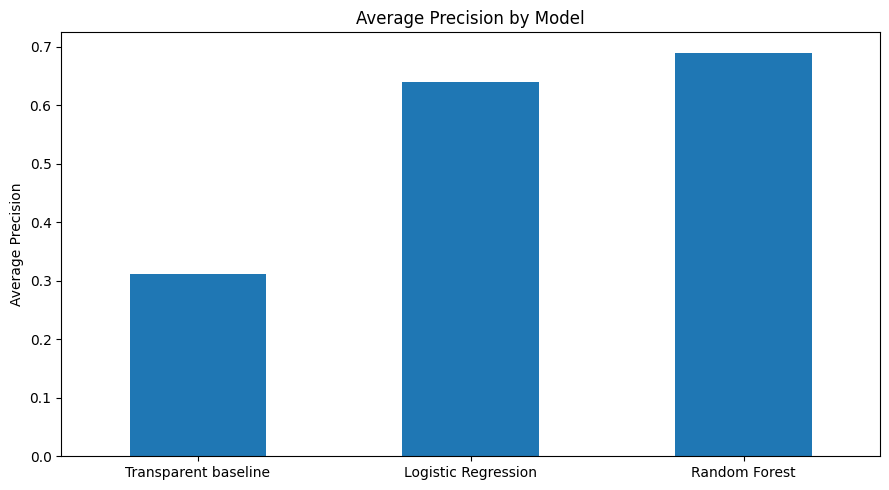

In [41]:
import matplotlib.pyplot as plt

results.set_index("Model")["Average Precision"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Precision by Model")
plt.ylabel("Average Precision")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

# 5. Limitations & Honest Framing

This analysis identifies pages whose observed historical signals are associated with future deterioration. It does not demonstrate that refreshing a page will cause its performance to improve.

The target is a constructed decision-support label based on observed changes in impressions, clicks, and sessions. It is therefore not a direct measurement of whether a page actually needed a content refresh.

The dataset contains aggregated search and engagement signals rather than detailed editorial information. Factors such as content quality, search intent, competition, seasonality, technical issues, and external events may influence performance.

The model should therefore be interpreted as a prioritization system rather than an automated decision maker.

The ranked output is best used as a queue for human review.

The analysis also does not prove anything about Google's ranking algorithm or establish causal relationships between content changes and search performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Choose best model

In [43]:
if rf_ap >= logistic_ap:
    best_scores = rf_probability
    best_model_name = "Random Forest"
else:
    best_scores = model_probability
    best_model_name = "Logistic Regression"

print("Selected ranking model:", best_model_name)

Selected ranking model: Random Forest


# Create ranked test dataset

In [44]:
recommendations = df.loc[test_mask].copy()

recommendations["model_score"] = best_scores

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    recommendations.index + 1
)

recommendations.head(20)

,cutoff_date,content_hash_id,hist_impressions,hist_clicks,hist_avg_position,hist_sessions,hist_engaged_sessions,hist_engagement_sec,hist_active_days,future_impressions,...,log_impressions,log_clicks,log_sessions,position_risk,low_ctr_signal,low_engagement_signal,declining_signal,baseline_score,model_score,rank
0,2026-04-29,content_97afac968d13d7e1,2.0,2.0,1.000000,2.0,0.0,0.0,28,2.0,...,1.098612,1.098612,1.098612,0,0,1,1,2,0.996143,1
1,2026-04-15,content_0ff870bb72605de4,3.0,2.0,1.000000,2.0,0.0,0.0,28,1.0,...,1.386294,1.098612,1.098612,0,0,1,1,2,0.996051,2
2,2026-04-15,content_29bbf1686c3d7479,3.0,2.0,1.666667,2.0,0.0,0.0,28,2.0,...,1.386294,1.098612,1.098612,0,0,1,1,2,0.996051,3
3,2026-05-27,content_a527fc9e04487612,3.0,2.0,3.000000,2.0,0.0,0.0,28,0.0,...,1.386294,1.098612,1.098612,0,0,1,1,2,0.995977,4
4,2026-05-13,content_97afac968d13d7e1,3.0,2.0,2.000000,2.0,0.0,0.0,28,2.0,...,1.386294,1.098612,1.098612,0,0,1,1,2,0.995961,5
5,2026-05-27,content_62f64aabbdeaaee5,4.0,2.0,1.166667,2.0,0.0,0.0,28,0.0,...,1.609438,1.098612,1.098612,0,0,1,1,2,0.995889,6
6,2026-04-15,content_81433a2ecceb87d5,3.0,2.0,3.333333,1.0,0.0,0.0,28,2.0,...,1.386294,1.098612,0.693147,0,0,1,1,2,0.995877,7
7,2026-04-15,content_2b03be9fca3ff2f0,4.0,2.0,2.166667,2.0,0.0,0.0,28,1.0,...,1.609438,1.098612,1.098612,0,0,1,1,2,0.995818,8
8,2026-05-27,content_502912587942f080,2.0,1.0,1.000000,1.0,1.0,73.0,28,0.0,...,1.098612,0.693147,0.693147,0,0,0,1,1,0.995808,9
9,2026-05-27,content_2197e50574bb4e84,2.0,1.0,1.000000,1.0,0.0,0.0,28,4.0,...,1.098612,0.693147,0.693147,0,0,1,1,2,0.995770,10


#Reason codes

In [45]:
def get_reason_codes(row):

    reasons = []

    if row["impression_change"] <= -0.20:
        reasons.append("impressions declining")

    if row["click_change"] <= -0.20:
        reasons.append("clicks declining")

    if row["session_change"] <= -0.20:
        reasons.append("sessions declining")

    if row["hist_avg_position"] >= 10:
        reasons.append("weaker visibility")

    if row["hist_ctr"] < 0.03:
        reasons.append("low CTR")

    if row["hist_engagement_rate"] < 0.40:
        reasons.append("low engagement")

    if not reasons:
        reasons.append("multiple review signals")

    return "; ".join(reasons)


recommendations["reason_codes"] = recommendations.apply(
    get_reason_codes,
    axis=1
)

# Suggested action

In [46]:
def suggest_action(row):

    decline_count = row["decline_signals"]

    if decline_count >= 2:
        return "Refresh / Review"

    if (
        row["hist_impressions"] > 0
        and row["hist_ctr"] < 0.03
    ):
        return "CTR Review"

    if row["hist_avg_position"] >= 10:
        return "Visibility Review"

    if row["hist_engagement_rate"] < 0.40:
        return "Engagement Review"

    return "Monitor"


recommendations["suggested_action"] = recommendations.apply(
    suggest_action,
    axis=1
)

#Confidence

In [47]:
def confidence_label(score):

    if score >= 0.75:
        return "High"

    if score >= 0.50:
        return "Medium"

    return "Low"


recommendations["confidence"] = recommendations[
    "model_score"
].apply(confidence_label)

# FINAL TOP 20

In [48]:
top20 = recommendations[
    [
        "rank",
        "content_hash_id",
        "model_score",
        "suggested_action",
        "reason_codes",
        "confidence"
    ]
].head(20)

top20

,rank,content_hash_id,model_score,suggested_action,reason_codes,confidence
0,1,content_97afac968d13d7e1,0.996143,Refresh / Review,clicks declining; sessions declining; low enga...,High
1,2,content_0ff870bb72605de4,0.996051,Refresh / Review,impressions declining; clicks declining; sessi...,High
2,3,content_29bbf1686c3d7479,0.996051,Refresh / Review,impressions declining; clicks declining; sessi...,High
3,4,content_a527fc9e04487612,0.995977,Refresh / Review,impressions declining; clicks declining; sessi...,High
4,5,content_97afac968d13d7e1,0.995961,Refresh / Review,impressions declining; clicks declining; sessi...,High
5,6,content_62f64aabbdeaaee5,0.995889,Refresh / Review,impressions declining; clicks declining; sessi...,High
6,7,content_81433a2ecceb87d5,0.995877,Refresh / Review,impressions declining; clicks declining; sessi...,High
7,8,content_2b03be9fca3ff2f0,0.995818,Refresh / Review,impressions declining; clicks declining; sessi...,High
8,9,content_502912587942f080,0.995808,Refresh / Review,impressions declining; clicks declining; sessi...,High
9,10,content_2197e50574bb4e84,0.995770,Refresh / Review,clicks declining; sessions declining; low enga...,High


## Action Playbook

The ranked queue is intended to help a reviewer decide where to start.

### Refresh / Review

Pages showing multiple declining signals should receive the highest review priority.

### CTR Review

Pages with visibility but relatively weak click capture can be reviewed for title and metadata opportunities.

### Visibility Review

Pages with weaker observed average position can be investigated for content depth, relevance, internal linking, or competitive changes.

### Engagement Review

Pages with relatively low engagement signals can be reviewed for content usefulness, structure, intent alignment, and user experience.

### Monitor

Pages without strong deterioration signals can remain in the monitoring queue rather than being automatically changed.

These actions are recommendations for human review, not automated editorial decisions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# Score distribution

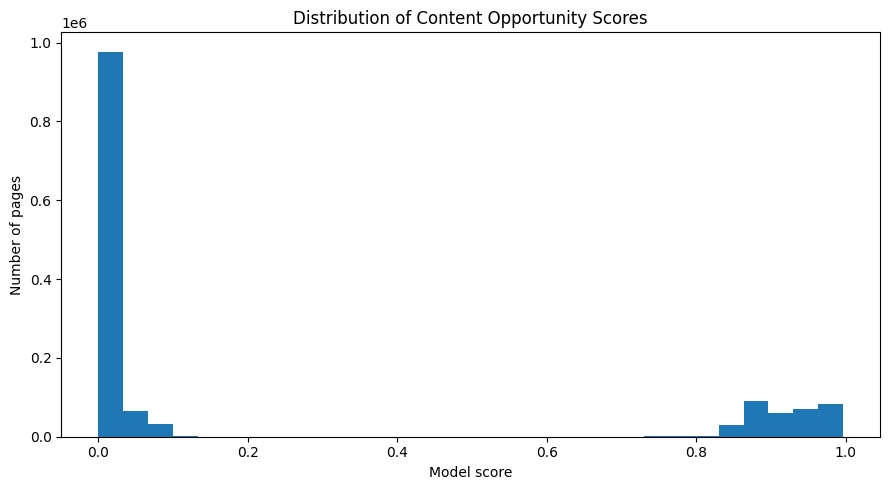

In [49]:
plt.figure(figsize=(9, 5))

plt.hist(
    recommendations["model_score"],
    bins=30
)

plt.title("Distribution of Content Opportunity Scores")
plt.xlabel("Model score")
plt.ylabel("Number of pages")

plt.tight_layout()
plt.show()

# Top 20 score chart

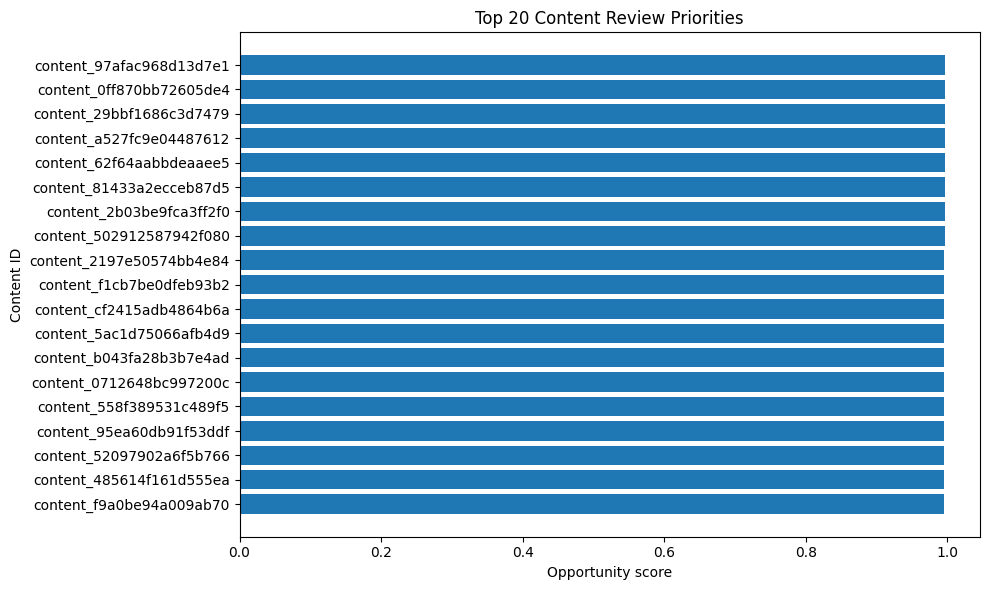

In [50]:
top20_plot = recommendations.head(20).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top20_plot["content_hash_id"].astype(str),
    top20_plot["model_score"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Content Review Priorities")
plt.xlabel("Opportunity score")
plt.ylabel("Content ID")

plt.tight_layout()
plt.show()

# Action distribution

In [51]:
action_counts = recommendations[
    "suggested_action"
].value_counts()

action_counts

,count
suggested_action,
Engagement Review,628800
CTR Review,587058
Refresh / Review,200149
Visibility Review,1286
Monitor,1171


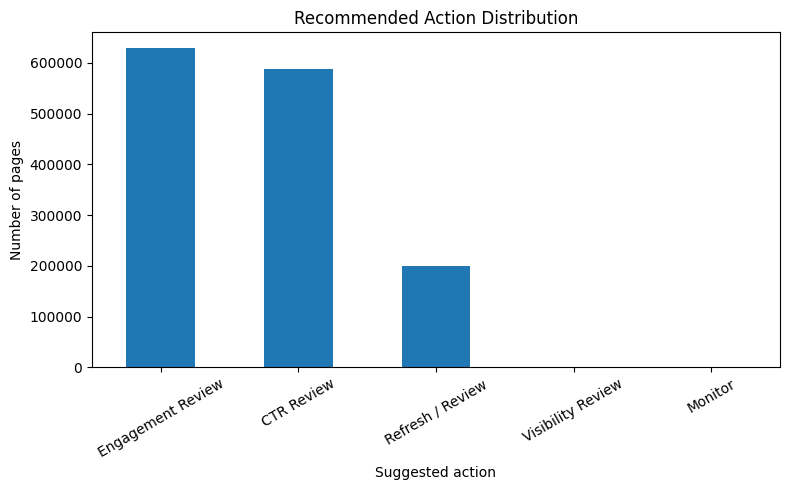

In [52]:
plt.figure(figsize=(8, 5))

action_counts.plot(
    kind="bar"
)

plt.title("Recommended Action Distribution")
plt.xlabel("Suggested action")
plt.ylabel("Number of pages")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Save final recommendations

In [ ]:
top20.to_csv(
    "top20_content_recommendations.csv",
    index=False
)

results.to_csv(
    "model_results.csv",
    index=False
)

print("Artifacts saved successfully.")

# SECTION 8 — ABSTRACT

# Abstract

This study asks which pages should be reviewed first for content refresh, expansion, protection, pruning, or monitoring. Using the FlyRank internship warehouse, page-level search and engagement signals are aggregated into repeated 28-day historical feature windows and evaluated against subsequent 28-day performance. A transparent decline-based baseline is compared with machine-learning ranking models using chronological validation to reduce temporal leakage. The strongest model provides a ranked queue of pages with reason codes and confidence labels for human review. The resulting system is intended as directional decision support and does not claim that refreshing a recommended page will causally improve future performance.

# SECTION 9 — ACKNOWLEDGMENTS

# Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

This project was developed as part of the FlyRank ML Internship capstone. The analysis uses public-safe, pseudonymized identifiers and does not expose client names, domains, URLs, private queries, or credentials.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
